In [7]:
#print S&P 
import pandas as pd
import yfinance as yf

spy = yf.download("SPY", start="2021-01-01", end="2026-05-01")
print(spy.round(2))

[*********************100%***********************]  1 of 1 completed

Price        Close    High     Low    Open     Volume
Ticker         SPY     SPY     SPY     SPY        SPY
2021-01-04  343.32  349.52  339.62  349.39  110210800
2021-01-05  345.68  346.77  342.63  342.68   66426200
2021-01-06  347.75  350.94  343.63  344.18  107997700
2021-01-07  352.92  353.66  349.95  350.12   68766800
2021-01-08  354.93  355.14  351.06  354.30   71677200
...            ...     ...     ...     ...        ...
2026-04-24  713.94  714.47  709.01  710.75   45182000
2026-04-27  715.17  715.63  712.30  713.17   33135900
2026-04-28  711.69  712.88  709.25  711.82   43117400
2026-04-29  711.58  712.20  708.37  711.00   41859200
2026-04-30  718.66  719.79  710.45  714.63   67240900

[1337 rows x 5 columns]


In [8]:
#add year and daiy return columns (same as in practice 1) 
spy["Year"] = spy.index.year
spy["Daily Return"] = spy["Close"].pct_change()
spy = spy.dropna()
print(spy.round(4))

Price          Close      High       Low      Open     Volume  Year  \
Ticker           SPY       SPY       SPY       SPY        SPY         
2021-01-05  345.6837  346.7729  342.6303  342.6768   66426200  2021   
2021-01-06  347.7504  350.9435  343.6263  344.1756  107997700  2021   
2021-01-07  352.9171  353.6618  349.9474  350.1243   68766800  2021   
2021-01-08  354.9279  355.1420  351.0552  354.3041   71677200  2021   
2021-01-11  352.5354  354.2949  351.6324  351.7534   51034700  2021   
...              ...       ...       ...       ...        ...   ...   
2026-04-24  713.9400  714.4700  709.0100  710.7500   45182000  2026   
2026-04-27  715.1700  715.6300  712.3000  713.1700   33135900  2026   
2026-04-28  711.6900  712.8800  709.2500  711.8200   43117400  2026   
2026-04-29  711.5800  712.2000  708.3700  711.0000   41859200  2026   
2026-04-30  718.6600  719.7900  710.4500  714.6300   67240900  2026   

Price      Daily Return  
Ticker                   
2021-01-05       0.0069 

In [9]:
#use groupby function to separate averages based on year 
spy.groupby("Year").mean().round(5)

Price,Close,High,Low,Open,Volume,Daily Return
Ticker,SPY,SPY,SPY,SPY,SPY,
Year,,,,,,
2021,399.36418,401.03655,397.21473,399.19429,7.365015e+07,0.00109
2022,388.02632,391.47668,384.37302,388.12433,9.475961e+07,-0.00068
2023,412.34619,414.27932,410.01165,412.06222,8.193056e+07,0.00096
2024,529.75441,531.99101,527.13239,529.75103,5.741187e+07,0.00091
2025,614.19819,617.33955,610.34154,614.02339,7.244500e+07,0.00073
2026,682.13694,685.35313,678.02172,681.68975,8.109354e+07,0.00071


In [10]:
#use groupby function to find daily return stats based on year 
spy.groupby("Year")["Daily Return"].agg(["max", "min", "mean", "median"])

,max,min,mean,median
Year,,,,
2021,0.024240,-0.024441,0.001094,0.001347
2022,0.054954,-0.043483,-0.000683,-0.001718
2023,0.022932,-0.020061,0.000964,0.000713
2024,0.024866,-0.029803,0.000914,0.001033
2025,0.105019,-0.058543,0.000727,0.001327
2026,0.029068,-0.020357,0.000713,0.000504


In [11]:
#practice merging dataframes 
df1 = pd.DataFrame({"Name" : ["Alice", "Bob", "Charlie", "Dana"], "Score" : [100, 80, 65, 96]})
df2 = pd.DataFrame({"Name" : ["Alice", "Bob", "Charlie", "Dana"], "Grade" : ["A+", "B-", "D", "A"]})

merged = pd.merge(df1, df2, on="Name")
print(merged)

      Name  Score Grade
0    Alice    100    A+
1      Bob     80    B-
2  Charlie     65     D
3     Dana     96     A


In [12]:
#create a table showing average monthly returns 
spy.columns = spy.columns.get_level_values(0) #flattens dataset 

#define columns 
spy["Daily Return"] = spy["Close"].pct_change()
spy["Year"] = spy.index.year
spy["Month"] = spy.index.month

#create pivot table 
spy.pivot_table(values="Daily Return", index="Year", columns="Month", aggfunc="mean").round(4)

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2021,-0.0001,0.0015,0.0020,0.0025,0.0004,0.0010,0.0012,0.0013,-0.0022,0.0033,-0.0004,0.0021
2022,-0.0026,-0.0015,0.0017,-0.0045,0.0003,-0.0039,0.0045,-0.0017,-0.0045,0.0039,0.0027,-0.0028
2023,0.0031,-0.0013,0.0016,0.0009,0.0002,0.0030,0.0016,-0.0007,-0.0024,-0.0010,0.0042,0.0023
2024,0.0008,0.0026,0.0016,-0.0018,0.0023,0.0018,0.0006,0.0011,0.0011,-0.0004,0.0029,-0.0011
2025,0.0014,-0.0006,-0.0026,0.0001,0.0030,0.0025,0.0010,0.0010,0.0017,0.0011,0.0001,0.0001
2026,0.0008,-0.0004,-0.0022,0.0048,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
#show when day-end movement is positive or negative
spy["Direction"] = spy["Daily Return"].apply(lambda x : "Up" if x > 0 else "Down")
spy["Direction"].value_counts()

Direction
Up      728
Down    608
Name: count, dtype: int64

In [14]:
#define rolling means
spy["20d Mean"] = spy["Close"].rolling(window=20).mean()
spy["50d Mean"] = spy["Close"].rolling(window=50).mean()

In [15]:
#define rolling volatility 
spy["20d Volatility"] = spy["Close"].rolling(window=20).std()

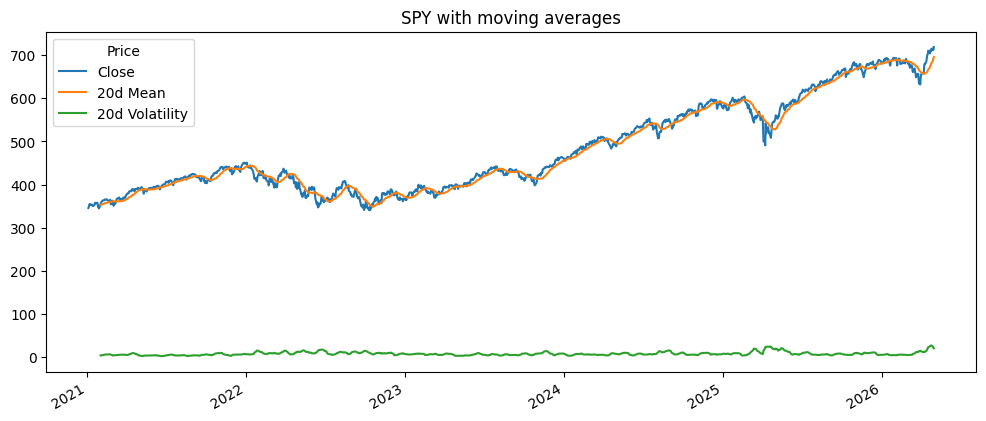

In [17]:
#plot S&P with moving averages (line chart) 
import matplotlib.pyplot as plt
spy[["Close", "20d Mean", "20d Volatility"]].plot(title="SPY with moving averages", figsize=(12,5))
plt.show()

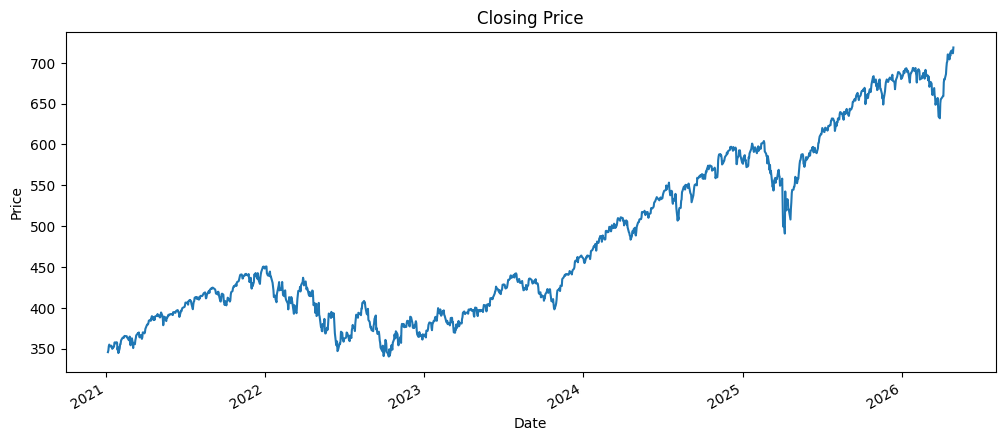

In [18]:
#plot closing prices over time (line chart) 
spy["Close"].plot(title="Closing Price", figsize=(12,5))
plt.xlabel("Date")
plt.ylabel("Price") 
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

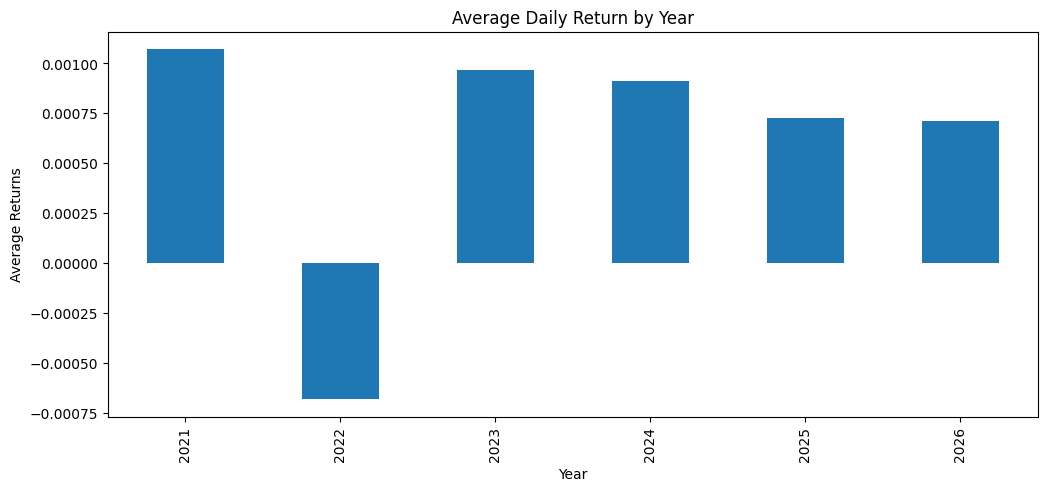

In [19]:
#plot average daily return by year (bar graph) 
annual_returns = spy.groupby("Year")["Daily Return"].mean()
annual_returns.plot(kind="bar", title="Average Daily Return by Year", figsize=(12, 5))
plt.ylabel("Average Returns") 
plt.show

Text(0.5, 0, 'Daily Return')

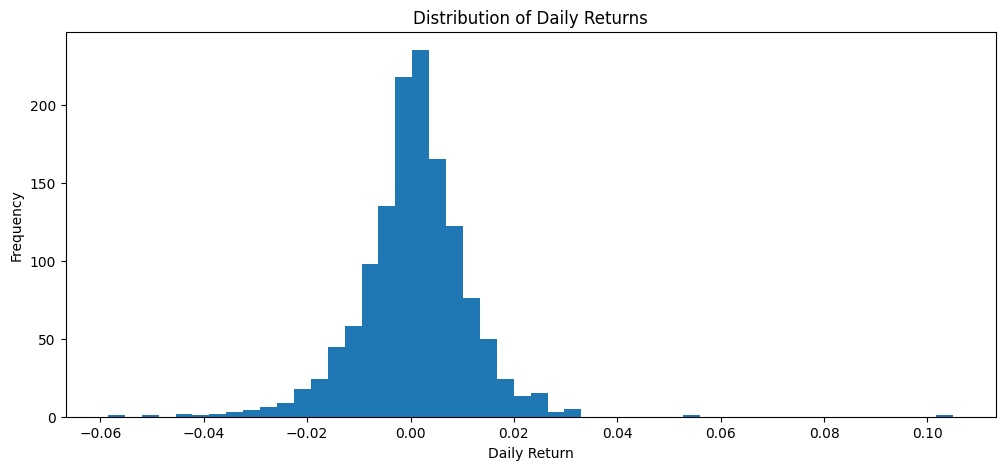

In [20]:
#print the distribution of daily returns (histogram) 
spy["Daily Return"].plot(kind="hist", bins=50, title="Distribution of Daily Returns", figsize=(12, 5))
plt.xlabel("Daily Return") 

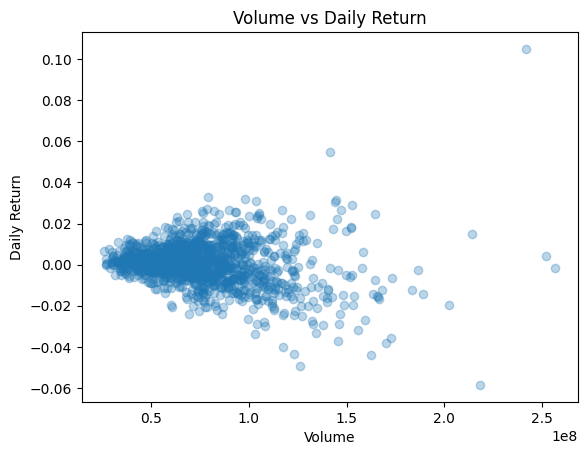

<Figure size 1000x500 with 0 Axes>

In [22]:
#plot volume vs daily return (scatterplot) 
plt.scatter(spy["Volume"], spy["Daily Return"], alpha=0.3)
plt.title("Volume vs Daily Return")
plt.xlabel("Volume")
plt.ylabel("Daily Return")
plt.figure(figsize=(10,5))
plt.show()